<a href="https://colab.research.google.com/github/dishatal/CREDIT-RISK-ASSESSMENT-USING-NAIVE-BAYES-THEOREM/blob/Notebook/GermanCreditRiskAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***WEEK 2*** :  Dataset loaded in Colab · Column table · Missing value check · Charts & observations

Saving german_credit_data.csv to german_credit_data (1).csv
Dataset Loaded Successfully

Shape of dataset:
(1000, 10)

First 5 rows:
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (t

/tmp/ipykernel_148/767566149.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Saving accounts"].fillna("No Account", inplace=True)
/tmp/ipykernel_148/767566149.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

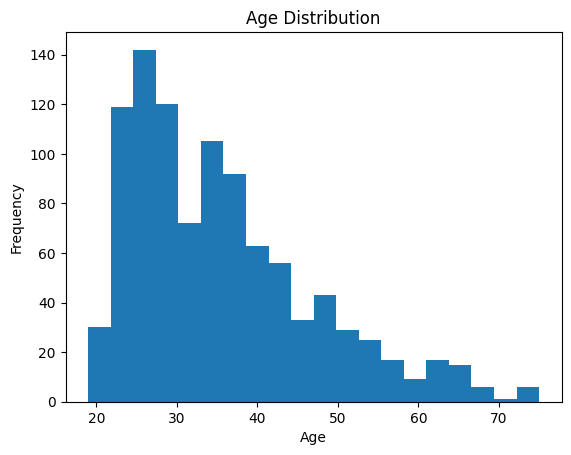

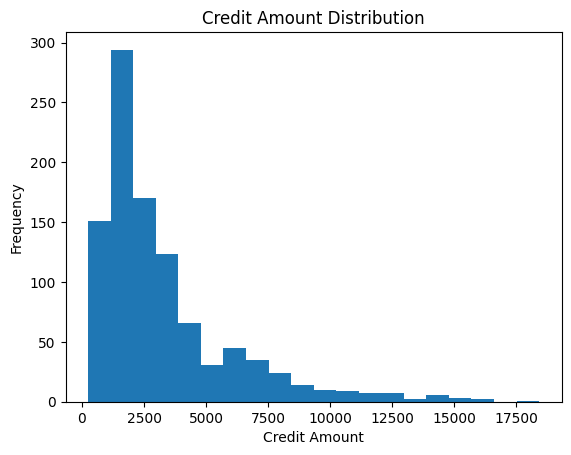

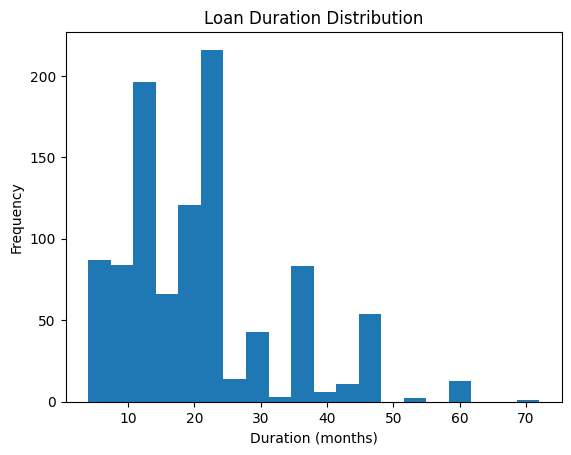

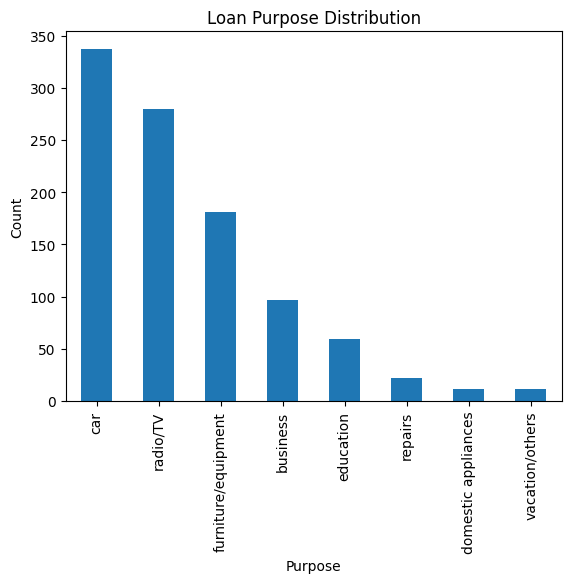


Analysis Completed Successfully


In [ ]:
# IMPORTING LIBRARIES


import pandas as pd
import matplotlib.pyplot as plt

#UPLOAD DATASET

from google.colab import files
uploaded = files.upload()

# read dataset
df = pd.read_csv("german_credit_data.csv")

print("Dataset Loaded Successfully")

#BASIC DATASET INFORMATION

print("\nShape of dataset:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset information:")
print(df.info())


#SUMMARY STATISTICS

print("\nSummary statistics:")
print(df.describe())


#COLUMN NAMES AND TYPES

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

#CHECK THE MISSING VALUES

print("\nMissing Values:")
print(df.isnull().sum())


#DATA CLEANING

#remove unnecessary index column
df = df.drop("Unnamed: 0", axis=1)

#fill missing categorical values
df["Saving accounts"].fillna("No Account", inplace=True)
df["Checking account"].fillna("No Account", inplace=True)

print("\nDataset cleaned successfully.")


#HISTOGRAMS FOR NUMERICAL DATA

#Age Histogram
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Credit Amount Histogram
plt.hist(df["Credit amount"], bins=20)
plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")
plt.show()

#Duration Histogram
plt.hist(df["Duration"], bins=20)
plt.title("Loan Duration Distribution")
plt.xlabel("Duration (months)")
plt.ylabel("Frequency")
plt.show()


#BAR CHART EXAMPLE (PURPOSE)

df["Purpose"].value_counts().plot(kind="bar")

plt.title("Loan Purpose Distribution")
plt.xlabel("Purpose")
plt.ylabel("Count")

plt.show()

print("\nAnalysis Completed Successfully")

***WEEK 3*** :  cleaned_data.csv · Encoded columns · Train/Test split · Preprocessing notes

In [ ]:

#IMPORTING THE LIBRARIES


import pandas as pd
from google.colab import files
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#UPLOADING THE DATASET

uploaded = files.upload()

df = pd.read_csv("german_credit_data.csv")

print("Dataset Loaded")
print(df.head())

#TASK A

#Remove unnecessary index column
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

#Handle missing values
#Numerical columns → fill with mean
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

#Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())


#Convert target column Risk to binary (if present)
if "Risk" in df.columns:
    df["Risk"] = df["Risk"].map({"Good":1, "Bad":0})

print("\nStudent A tasks completed.")



#TASK B

#Label Encoding for categorical columns
le = LabelEncoder()

for col in cat_cols:
    print("\nBefore Encoding:", df[col].unique()[:5])

    df[col] = le.fit_transform(df[col])

    print("After Encoding:", df[col].unique()[:5])

print("\nColumn Data Types After Encoding:")
print(df.dtypes)

print("\nStudent B tasks completed.")


#TASK C

#Split Features and Target
if "Risk" in df.columns:
    X = df.drop("Risk", axis=1)
    y = df["Risk"]
else:
    # If dataset doesn't contain Risk column
    X = df
    y = None

#Train Test Split (80/20)
if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print("\nTraining Set Shape:", X_train.shape)
    print("Test Set Shape:", X_test.shape)

print("\nStudent C tasks completed.")



#SAVING THE CLEAN DATASET

df.to_csv("cleaned_data.csv", index=False)

print("\nCleaned dataset saved as cleaned_data.csv")

files.download("cleaned_data.csv")

Saving german_credit_data.csv to german_credit_data (2).csv
Dataset Loaded
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  

Missing values after cleaning:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Cred

/tmp/ipykernel_148/3946344998.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

***WEEK 4*** : Trained GNB model · Accuracy, Confusion Matrix, Classification Report · All screenshots in doc

Saving cleaned_data.csv to cleaned_data (2).csv
Dataset Loaded Successfully

Columns in dataset:
Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose'],
      dtype='object')

Target Column: Purpose

Training Data Shape: (800, 8)
Testing Data Shape: (200, 8)

Model Training Completed

First 10 Predictions:
[4 1 5 5 1 1 5 5 4 0]

Accuracy: 0.33

Confusion Matrix:
[[ 1  6  1  0  2  6  0  2]
 [ 3 20  0  0 14 23  1  2]
 [ 0  1  0  0  0  0  0  0]
 [ 0  6  0  0  4  4  0  1]
 [ 0 10  0  0 12 22  0  0]
 [ 1 11  0  0  8 33  1  0]
 [ 0  2  0  0  1  0  0  0]
 [ 0  2  0  0  0  0  0  0]]


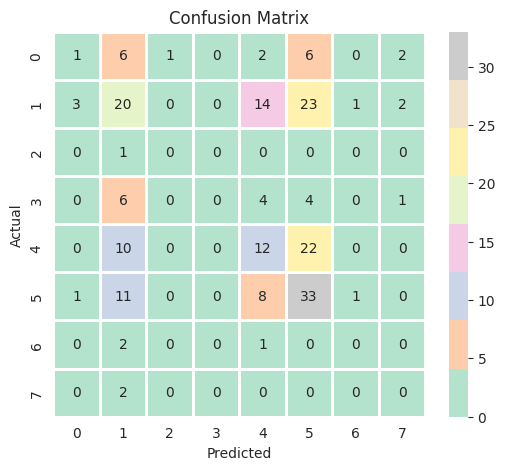


Classification Report:

              precision    recall  f1-score   support

           0       0.20      0.06      0.09        18
           1       0.34      0.32      0.33        63
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00        15
           4       0.29      0.27      0.28        44
           5       0.38      0.61      0.46        54
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         2

    accuracy                           0.33       200
   macro avg       0.15      0.16      0.15       200
weighted avg       0.29      0.33      0.30       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


# ===============================
# SET PASTEL GRAPH STYLE
# ===============================

sns.set_style("whitegrid")
sns.set_palette("pastel")


# ===============================
# UPLOAD DATASET
# ===============================

uploaded = files.upload()

# Load the uploaded CSV
df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset Loaded Successfully\n")


# ===============================
# CHECK COLUMN NAMES
# ===============================

print("Columns in dataset:")
print(df.columns)


# ===============================
# SPLIT FEATURES AND TARGET
# ===============================

target_column = df.columns[-1]   # last column assumed as target

X = df.drop(target_column, axis=1)
y = df[target_column]

print("\nTarget Column:", target_column)


# ===============================
# TRAIN TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# ===============================
# TRAIN NAIVE BAYES MODEL
# ===============================

model = GaussianNB()

model.fit(X_train, y_train)

print("\nModel Training Completed")


# ===============================
# MAKE PREDICTIONS
# ===============================

y_pred = model.predict(X_test)

print("\nFirst 10 Predictions:")
print(y_pred[:10])


# ===============================
# ACCURACY SCORE
# ===============================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


# ===============================
# CONFUSION MATRIX
# ===============================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ===============================
# PASTEL HEATMAP
# ===============================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Pastel2",
    linewidths=1,
    linecolor="white"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ===============================
# CLASSIFICATION REPORT
# ===============================

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ACCURACY ACHEIVED FROM THE ABOVE CODE: 0.33 OR 33%

Saving cleaned_data.csv to cleaned_data (3).csv
Dataset Loaded Successfully

Columns:
Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose'],
      dtype='object')

Target Column: Purpose

Model Training Completed

First 10 Predictions:
[4 1 5 5 1 1 5 5 4 0]

Accuracy: 0.325

Confusion Matrix:
[[ 1  6  1  0  2  6  0  2]
 [ 3 19  0  0 14 24  1  2]
 [ 0  0  0  0  0  1  0  0]
 [ 0  6  0  0  4  4  0  1]
 [ 0 10  0  0 12 22  0  0]
 [ 1 11  0  0  8 33  1  0]
 [ 0  2  0  0  1  0  0  0]
 [ 0  2  0  0  0  0  0  0]]


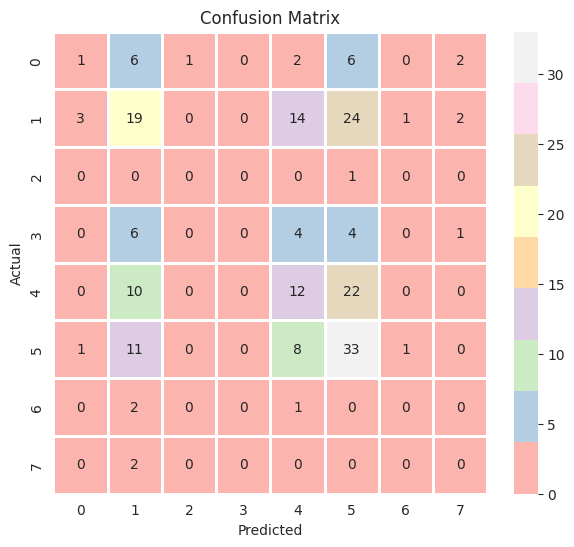


Classification Report:

              precision    recall  f1-score   support

           0       0.20      0.06      0.09        18
           1       0.34      0.30      0.32        63
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00        15
           4       0.29      0.27      0.28        44
           5       0.37      0.61      0.46        54
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         2

    accuracy                           0.33       200
   macro avg       0.15      0.16      0.14       200
weighted avg       0.29      0.33      0.29       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


# ===============================
# PASTEL GRAPH STYLE
# ===============================

sns.set_style("whitegrid")
sns.set_palette("pastel")


# ===============================
# UPLOAD DATASET
# ===============================

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset Loaded Successfully\n")

print("Columns:")
print(df.columns)


# ===============================
# SPLIT FEATURES AND TARGET
# ===============================

target_column = df.columns[-1]

X = df.drop(target_column, axis=1)
y = df[target_column]

print("\nTarget Column:", target_column)


# ===============================
# TRAIN TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===============================
# FEATURE SCALING (IMPROVEMENT)
# ===============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ===============================
# TRAIN MODEL
# ===============================

model = GaussianNB()

model.fit(X_train, y_train)

print("\nModel Training Completed")


# ===============================
# PREDICTIONS
# ===============================

y_pred = model.predict(X_test)

print("\nFirst 10 Predictions:")
print(y_pred[:10])


# ===============================
# ACCURACY
# ===============================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


# ===============================
# CONFUSION MATRIX
# ===============================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ===============================
# PASTEL HEATMAP
# ===============================

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Pastel1",
    linewidths=1,
    linecolor="white"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ===============================
# CLASSIFICATION REPORT
# ===============================

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

***WEEK 5*** : ANALYSIS

In [12]:
# ======================================
# WEEK 5 ANALYSIS
# ======================================

from sklearn.dummy import DummyClassifier
import numpy as np

print("===== WEEK 5 ANALYSIS =====\n")

# ------------------------------------------------
# 1. TEST MODEL WITH A PRETEND APPLICANT
# ------------------------------------------------

# Example fake applicant
# (values follow the same order as dataset columns)

applicant = [[35, 1, 2, 1, 1, 0, 5000, 24]]

# scale it using the same scaler
applicant_scaled = scaler.transform(applicant)

prediction = model.predict(applicant_scaled)

print("Pretend Applicant Prediction (Purpose Class):", prediction)


# ------------------------------------------------
# 2. DUMMY MODEL (BASELINE COMPARISON)
# ------------------------------------------------

dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_pred)

print("\nDummy Model Accuracy:", dummy_accuracy)


# ------------------------------------------------
# 3. COMPARE MODELS
# ------------------------------------------------

print("\nModel Accuracy:", accuracy)

if accuracy > dummy_accuracy:
    print("Our model performs better than the dummy baseline.")
else:
    print("Our model does not outperform the dummy baseline.")

===== WEEK 5 ANALYSIS =====

Pretend Applicant Prediction (Purpose Class): [5]

Dummy Model Accuracy: 0.315

Model Accuracy: 0.325
Our model performs better than the dummy baseline.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
